In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
SWIN_TRANSFORMER = 'swin_tiny_patch4_window7_224'
RESIDUAL_NEURAL_NETWORK = 'resnet50'

BACKBONE_CONFIG = {
    RESIDUAL_NEURAL_NETWORK: {'out_indices': [4]},
    SWIN_TRANSFORMER: {'out_indices': [3]}
}

In [ ]:
from torch import nn
import timm


class DirectionalResidualStack(nn.Module):

    def __init__(self, backbone_name="resnet50"):
        super().__init__()

        if backbone_name not in BACKBONE_CONFIG:
            raise ValueError(f"Backbone '{backbone_name}' not supported.")

        config = BACKBONE_CONFIG[backbone_name]

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            features_only=True,
            out_indices=config["out_indices"],
        )

        # get number of output channels from the backbone
        self.feature_dim = self.backbone.feature_info[-1]["num_chs"]

        print(f"--- DRS initialized with {backbone_name} ---")
        print(f"Feature dimension set to: {self.feature_dim}")

    def forward(self, img_ref, img_cur):
        print("\n[DRS] Entering forward pass...")
        ref_features = self.backbone(img_ref)[0]
        cur_features = self.backbone(img_cur)[0]
        print(f"[DRS] Shape of feature tensor from backbone: {ref_features.shape}")

        r_abs = torch.abs(cur_features - ref_features)
        print(f"[DRS] Shape of calculated r_abs: {r_abs.shape}")
        print("[DRS] Exiting forward pass.")
        return r_abs


class MaskedResidualModel(nn.Module):
    def __init__(self, drs_model, mask_ratio=0.6):
        super().__init__()
        self.drs = drs_model
        self.mask_ratio = mask_ratio
        self.encoder = nn.Sequential(
            nn.Linear(self.drs.feature_dim, self.drs.feature_dim), nn.GELU()
        )
        self.decoder = nn.Linear(self.drs.feature_dim, self.drs.feature_dim)
        self.mask_token = nn.Parameter(torch.randn(1, 1, self.drs.feature_dim))
        self.loss_fn = nn.MSELoss()

    def forward(self, img_ref, img_cur):
        r_abs = self.drs(img_ref, img_cur)
        batch = r_abs.shape[0]
        device = r_abs.device

        # correctly handles both
        # (B, C, H, W) from ResNet
        # and
        # (B, H, W, C) from Swin-T
        if r_abs.dim() == 4:
            # Check if channels are in ResNet format
            if r_abs.shape[1] > r_abs.shape[3]:
                r_abs = r_abs.permute(
                    0, 2, 3, 1
                )  # permute (B, C, H, W) -> (B, H, W, C)

            # reshape the unified (B, H, W, C) format to (B, H*W, C)
            patches = r_abs.reshape(batch, -1, self.drs.feature_dim)
        else:
            raise ValueError(f"Unsupported feature map shape: {r_abs.shape}")
        # end of correct handling

        num_patches = patches.shape[1]
        rand_indices = torch.rand(batch, num_patches, device=device).argsort(dim=-1)
        num_masked = int(self.mask_ratio * num_patches)
        masked_indices, unmasked_indices = (
            rand_indices[:, :num_masked],
            rand_indices[:, num_masked:],
        )

        batch_range = torch.arange(batch, device=device)[:, None]

        encoded_all_patches = self.encoder(patches)
        encoded_unmasked_patches = encoded_all_patches[batch_range, unmasked_indices]

        full_sequence = self.mask_token.expand(batch, num_patches, -1).clone()
        full_sequence[batch_range, unmasked_indices] = encoded_unmasked_patches

        reconstructed_patches_all = self.decoder(full_sequence)
        reconstructed_masked_patches = reconstructed_patches_all[
            batch_range, masked_indices
        ]
        original_masked_patches = patches[batch_range, masked_indices]

        loss = self.loss_fn(reconstructed_masked_patches, original_masked_patches)

        return {
            "loss": loss,
            "r_abs": r_abs,
            "patches": patches,
            "reconstructed_patches": reconstructed_patches_all,
            "masked_indices": masked_indices,
            "unmasked_indices": unmasked_indices,
        }

In [4]:
drs_resnet = DirectionalResidualStack(backbone_name='resnet50')
mrm_resnet_model = MaskedResidualModel(drs_resnet, mask_ratio=0.6)

# create dummy input images
ref_img = torch.randn(2, 3, 224, 224) # Batch size of 2
cur_img = torch.randn(2, 3, 224, 224)

mrm_resnet_output = mrm_resnet_model(ref_img, cur_img)

print(f"ResNet50 Backbone Feature Dimension: {drs_resnet.feature_dim}")
print(f"Reconstruction Loss: {mrm_resnet_output['loss'].item()}")

--- DRS initialized with resnet50 ---
Feature dimension set to: 2048

[DRS] Entering forward pass...
[DRS] Shape of feature tensor from backbone: torch.Size([2, 2048, 7, 7])
[DRS] Shape of calculated r_abs: torch.Size([2, 2048, 7, 7])
[DRS] Exiting forward pass.
ResNet50 Backbone Feature Dimension: 2048
Reconstruction Loss: 0.48679372668266296


In [5]:
print("--- Testing Swin-T ---")
try:
    drs_swin = DirectionalResidualStack(backbone_name=SWIN_TRANSFORMER)
    mrm_swin = MaskedResidualModel(drs_swin, mask_ratio=0.6).to(device)
    ref_img_swin = torch.randn(2, 3, 224, 224).to(device)
    cur_img_swin = torch.randn(2, 3, 224, 224).to(device)
    mrm_swin_output = mrm_swin(ref_img_swin, cur_img_swin)
    print(f"SwinTiny Backbone Feature Dimension: {drs_swin.feature_dim}")
    print(f"Reconstruction Loss: {mrm_swin_output['loss'].item()}")
    print("Swin-T test PASSED ✅")
except Exception as e:
    print(f"Swin-T test FAILED ❌\nError: {e}")

--- Testing Swin-T ---
--- DRS initialized with swin_tiny_patch4_window7_224 ---
Feature dimension set to: 768

[DRS] Entering forward pass...
[DRS] Shape of feature tensor from backbone: torch.Size([2, 7, 7, 768])
[DRS] Shape of calculated r_abs: torch.Size([2, 7, 7, 768])
[DRS] Exiting forward pass.
SwinTiny Backbone Feature Dimension: 768
Reconstruction Loss: 1.951995611190796
Swin-T test PASSED ✅


In [12]:
from matplotlib import pyplot as plt

def plot_mrm_results(model_output, sample_idx=0, backbone_name=''):
    """
    Plots the original difference, masked input, and reconstructed output.
    """
    # --- Prepare Tensors ---
    # Move all necessary data to CPU and detach from the graph for plotting
    with torch.no_grad():
        patches = model_output['patches'][sample_idx].cpu()
        reconstructed = model_output['reconstructed_patches'][sample_idx].cpu()
        masked_indices = model_output['masked_indices'][sample_idx].cpu()
        unmasked_indices = model_output['unmasked_indices'][sample_idx].cpu()

        # Determine the original grid size (e.g., 7x7)
        num_patches = patches.shape[0]
        height = width = int(num_patches**0.5)
        channels = patches.shape[1]

        # --- 1. Original Difference Image ---
        # Reshape patches to an image and take the mean across channels for a grayscale view
        original_img = patches.reshape(height, width, channels).mean(dim=-1)

        # --- 2. Masked Input Image ---
        # Create a copy and set the masked parts to a neutral value (gray)
        masked_patches_viz = patches.clone()
        masked_patches_viz[masked_indices] = torch.mean(patches) 
        masked_img = masked_patches_viz.reshape(height, width, channels).mean(dim=-1)

        # --- 3. Reconstructed Output Image ---
        # Create a canvas and fill it with the original unmasked patches
        # and the newly reconstructed masked patches.
        reconstructed_viz = torch.zeros_like(patches)
        reconstructed_viz[unmasked_indices] = patches[unmasked_indices]
        reconstructed_viz[masked_indices] = reconstructed[masked_indices]
        reconstructed_img = reconstructed_viz.reshape(height, width, channels).mean(dim=-1)

    # --- 4. Plotting ---
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    title = f'MRM Visualization for {backbone_name}'
    fig.suptitle(title, fontsize=20)
    
    axs[0].imshow(original_img, cmap='viridis')
    axs[0].set_title('Original Difference Map', fontsize=14)
    axs[0].axis('off')
    
    axs[1].imshow(masked_img, cmap='viridis')
    axs[1].set_title('Masked Input', fontsize=14)
    axs[1].axis('off')

    axs[2].imshow(reconstructed_img, cmap='viridis')
    axs[2].set_title('Reconstructed Output', fontsize=14)
    axs[2].axis('off')
    
    plt.show()

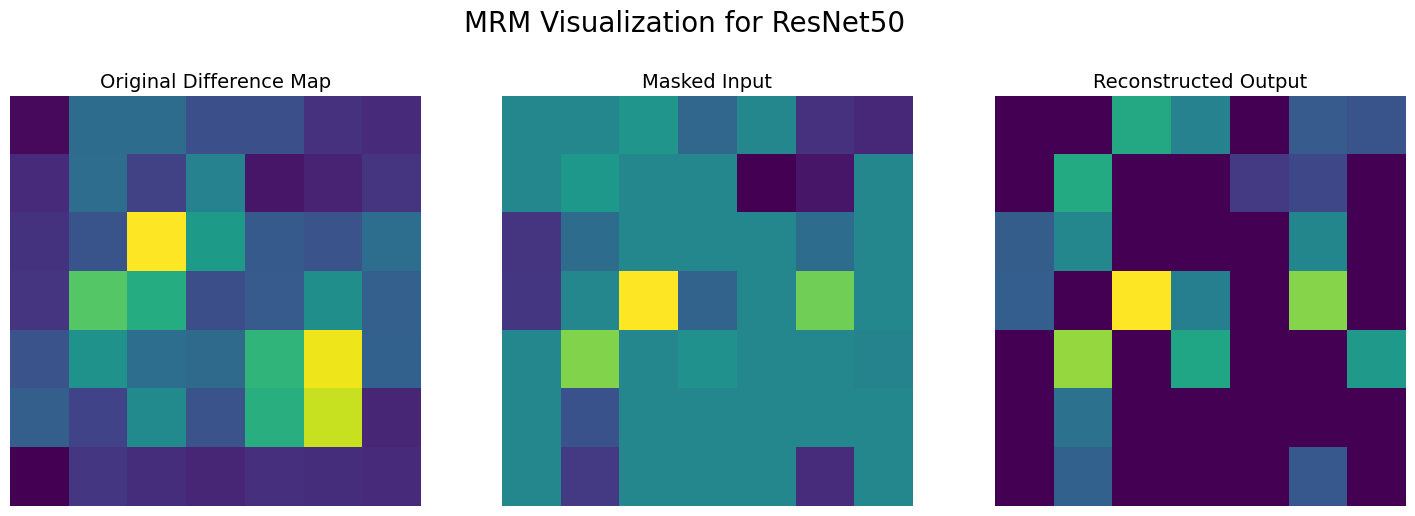

In [14]:
plot_mrm_results(mrm_resnet_output, sample_idx=0, backbone_name='ResNet50')

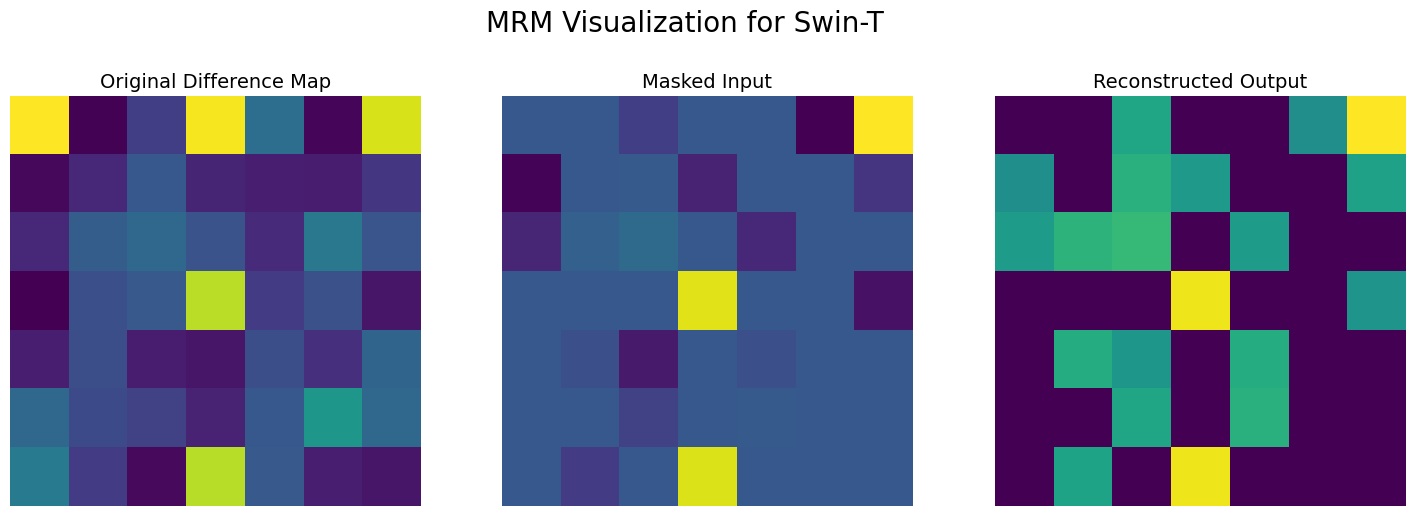

In [13]:
plot_mrm_results(mrm_swin_output, sample_idx=0, backbone_name='Swin-T')